In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stocks = ['AAPL', 'MSFT', 'GOOGL']
data = yf.download(stocks, start='2022-01-01')['Close']

data.head()


C:\Users\Hassan\AppData\Local\Temp\ipykernel_1384\3157426409.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2022-01-01')['Close']
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOGL,MSFT
Date,,,
2022-01-03,178.270309,143.904205,323.898346
2022-01-04,176.007751,143.316650,318.344421
2022-01-05,171.325989,136.741806,306.123871
2022-01-06,168.465988,136.714508,303.704926
2022-01-07,168.632492,135.989487,303.859741


In [3]:
daily_returns = data.pct_change().dropna()
daily_returns.head()


Ticker,AAPL,GOOGL,MSFT
Date,,,
2022-01-04,-0.012692,-0.004083,-0.017147
2022-01-05,-0.026600,-0.045876,-0.038388
2022-01-06,-0.016693,-0.000200,-0.007902
2022-01-07,0.000988,-0.005303,0.000510
2022-01-10,0.000116,0.012060,0.000732


In [4]:
mean_daily_returns = daily_returns.mean()
mean_daily_returns


Ticker
AAPL     0.000596
GOOGL    0.000981
MSFT     0.000529
dtype: float64

In [5]:
cov_matrix = daily_returns.cov()
cov_matrix


Ticker,AAPL,GOOGL,MSFT
Ticker,,,
AAPL,0.000326,0.000218,0.000192
GOOGL,0.000218,0.000426,0.000222
MSFT,0.000192,0.000222,0.000287


In [6]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    portfolio_return = np.dot(weights, mean_daily_returns) * 252
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    portfolio_risk = np.sqrt(portfolio_variance)
    
    results[0, i] = portfolio_return
    results[1, i] = portfolio_risk
    results[2, i] = portfolio_return / portfolio_risk  # Sharpe (Rf = 0)


In [7]:
max_sharpe_idx = np.argmax(results[2])
min_var_idx = np.argmin(results[1])

max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_risk = results[1, max_sharpe_idx]

min_var_return = results[0, min_var_idx]
min_var_risk = results[1, min_var_idx]


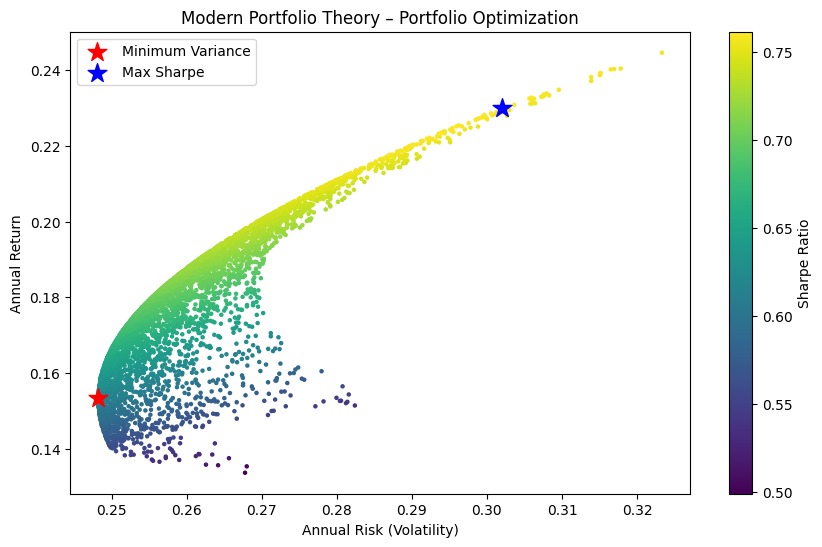

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', s=5)
plt.colorbar(label='Sharpe Ratio')

plt.scatter(min_var_risk, min_var_return, color='red', marker='*', s=200, label='Minimum Variance')
plt.scatter(max_sharpe_risk, max_sharpe_return, color='blue', marker='*', s=200, label='Max Sharpe')

plt.xlabel('Annual Risk (Volatility)')
plt.ylabel('Annual Return')
plt.title('Modern Portfolio Theory – Portfolio Optimization')
plt.legend()
plt.show()


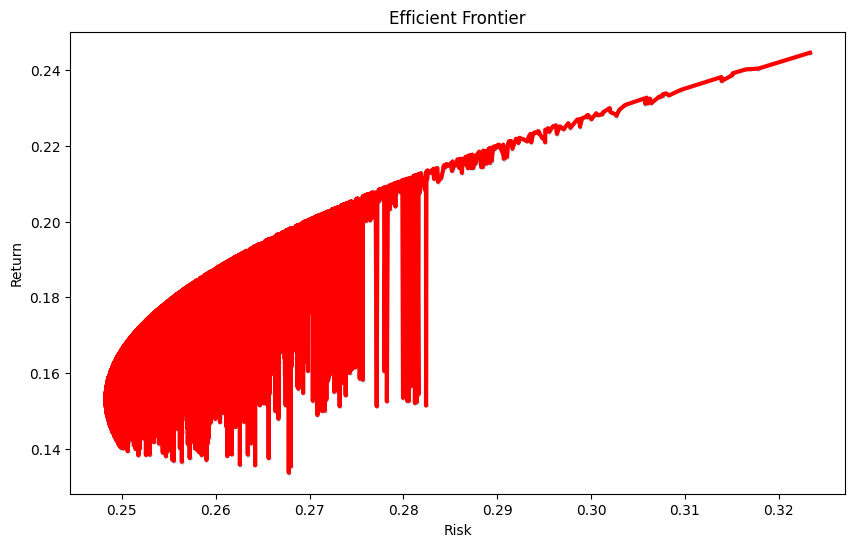

In [9]:
df = pd.DataFrame({
    'Return': results[0],
    'Risk': results[1]
})

efficient_frontier = df.groupby('Risk')['Return'].max()

plt.figure(figsize=(10,6))
plt.plot(efficient_frontier.index, efficient_frontier.values, 'r-', linewidth=3)
plt.scatter(results[1], results[0], s=5, alpha=0.3)

plt.xlabel('Risk')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.show()
